### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [84]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [85]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [86]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation m'

In [87]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [88]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [89]:
tavily.invoke("Provide me the recent AI news for march 3rd 2025")

[{'title': 'March 2025 - The Artificial Intelligence Revolution',
  'url': 'https://choreoadvisors.com/market-perspectives/march-2025-the-artificial-intelligence-revolution',
  'content': 'There are plenty of signs that AI is beginning to have a material effect on the world. One of the early signals may be the valuation of AI-related private companies such as OpenAI. Investors are willing to pay up for what they believe could be a potential leader in the field. The ChatGPT maker’s most recent funding round in the private markets valued the company at $300 billion. At current markets as of 3/3/25, this would place it as the 27th largest company in the S&P 500, a staggering valuation for a private entity. [...] There are risks abounding in the technology itself and the rapidly evolving investment landscape surrounding AI. Often with new technology, the initial spend is high as an arms race of sorts ensues. Also of note, the first companies and technology paths are often not the ultimate 

In [90]:
### Combine all the tools in the list

tools=[wiki,tavily]

In [91]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")

llm_with_tools=llm.bind_tools(tools)

In [92]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent AI news. I need to figure out which tool to use here. The available tools are Wikipedia and Tavily Search. Wikipedia is good for general knowledge and historical information, but since the user is asking about recent news, that\'s probably going to be covered by Tavily Search, which is optimized for current events. So I should use the tavily_search_results_json function with the query "recent AI news". Let me make sure the parameters are correct. The function requires a query string, so the argument should be {"query": "recent AI news"}. Yep, that should do it.\n', 'tool_calls': [{'id': 'x2ced6q52', 'function': {'arguments': '{"query":"recent AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 159, 'prompt_tokens': 288, 'total_tokens': 447, 'completion_time': 0.308721235, 'completion_tokens_details': {'reasoning

In [93]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI News'},
  'id': 'ad7tev09y',
  'type': 'tool_call'}]

In [94]:
from langchain_community.tools import ShellTool
from langchain_community.tools import Tool
import numexpr

def calculator(expression: str):
    try:
        return str(numexpr.evaluate(expression))
    except Exception as e:
        return f"Error: {e}"

calculator_tool = Tool(
    name="Calculator",
    func=calculator,
    description="Useful for solving mathematical calculations."
)

In [95]:
from datetime import datetime
from langchain_community.tools import Tool

def current_datetime(_: str = ""):
    return datetime.now().strftime("%A, %d %B %Y %I:%M:%S %p")

datetime_tool = Tool(
    name="current_datetime",
    func=current_datetime,
    description="Returns the current local date and time."
)

In [96]:
tools=[wiki,tavily,calculator_tool,datetime_tool]

In [97]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [98]:
llm_with_tools=llm.bind_tools(tools)

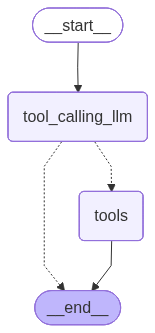

In [99]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [100]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (p3v07tp8s)
 Call ID: p3v07tp8s
  Args:
    query: top 10 AI news March 3 2025
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Top Viral AI & Tech News (March 3 - March 7, 2025)", "url": "https://www.youtube.com/watch?v=n0icz4P221E", "content": "exciting times. All right, let's go to the next piece. Y'all got me going in\nthe comments. All right, so Next piece of news, AI is taking over\ndating apps. So, MatchGroup, which is the parent company who bought out\nTinder, Hinge, and OKCID, is introducing AI powered assistance to help users pick\nthe best profile picture and craft messages that increase their chances of\ngetting a response. This could mean no

In [105]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (rzcpjs4zz)
 Call ID: rzcpjs4zz
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation m


In [106]:
messages=graph.invoke({"messages":HumanMessage(content="What is the current date and time")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the current date and time
================================== Ai Message ==================================
Tool Calls:
  current_datetime (apwhkdbwt)
 Call ID: apwhkdbwt
  Args:
    __arg1:
================================= Tool Message =================================
Name: current_datetime

Friday, 17 July 2026 11:36:48 PM
